### Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os
import math
import warnings
import numpy as np
warnings.filterwarnings('ignore')


import scimap

Running SCIMAP  2.3.5


#### Set color palette for visualizations

In [2]:
colors_palette = [
'#ebac23', 
'#b80058', #lipstick 0,140,249 
'#008cf9', #azure 0,110,0 
'#006e00', #green 0,187,173 
'#00bbad', #caribbean 209,99,230 
'#d163e6', #lavender 178,69,2 cd 
'#b24502', #brown 255,146,135 
'#ff9287', #coral 89,84,214 
'#5954d6', #indigo 0,198,248 
'#00c6f8', #turquoise 135,133,0 
'#878500', #olive 0,167,108 
'#00a76c', #jade 189,189,189 
'#274d52', #plantation 199,162,166 
'#c7a2a6', #eunry 129,139,112 
'#818b70', #battleship 96,78,60 
'#604e3c', #kabul 140,159,183 
'#8c9fb7', #balihai 121,104,128 
'#796880', #rum,
'#56641a', #fernfrond 192,175,251 
'#c0affb', #perfume 230,161,118 
'#e6a176', #apricot 0,103,138 
'#00678a', #orient 152,68,100 
'#984464', #vinrouge 94,204,171 
'#5eccab', #downy
'#bdbdbd'] #gray

#### Set file paths and directories

In [3]:
root = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/'
data_dir = root+'data/'
out = root+'out_july2025_xenium/'

merged_dir = os.listdir(out + 'script09a_rctd_spatial_clustering/')

save_dir = out + 'script09b_spatial_clustering_figures_gbm/'
os.makedirs(save_dir, exist_ok=True)


merged_adatas = os.listdir(out + 'script09a_rctd_spatial_clustering/')
merged_adatas = [x for x in merged_adatas if x.endswith('.h5ad')]
merged_adatas = [x for x in merged_adatas if 'subset' in x]

In [4]:
gbm = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'gbm' in file][0]
ol = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'ol' in file][0]
aa = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'aa' in file][0]

In [5]:
data = gbm
data

AnnData object with n_obs × n_vars = 91325 × 216
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core_id',

In [6]:
gbm.obs['rctd_cell_type'].unique().tolist()


[nan,
 'Neuron',
 'MES-like',
 'Mural cell',
 'OPC',
 'Plasma B',
 'B cell',
 'Endothelial',
 'Astrocyte',
 'RG',
 'NPC-like',
 'Mast',
 'Oligodendrocyte',
 'AC-like',
 'DC',
 'TAM-MG',
 'CD4_CD8',
 'Neutrophil',
 'NK',
 'TAM-BDM',
 'OPC-like',
 'Mono']

In [7]:
target_res = 'leiden_harmony_r0.5'
sample_name = 'gbm'

In [8]:
df = data.obs[['core_id', 'Region', 'rctd_cell_type', target_res]]
df

,core_id,Region,rctd_cell_type,leiden_harmony_r0.5
mdcnhijp-1-0,GBM2-Edge,Edge,NaN,1
mccimicb-1-0,GBM2-Edge,Edge,Neuron,1
lcemmbcd-1-0,GBM2-Edge,Edge,NaN,0
maleanbh-1-0,GBM2-Edge,Edge,NaN,6
mcpbebeb-1-0,GBM2-Edge,Edge,MES-like,3
...,...,...,...,...
ihleocjf-1-19,GBM10-Core,Core,NaN,2
hacjkkef-1-19,GBM10-Core,Core,NaN,8
ahnoioli-1-19,GBM10-Core,Core,NaN,8
hefhopdn-1-19,GBM10-Core,Core,NaN,8


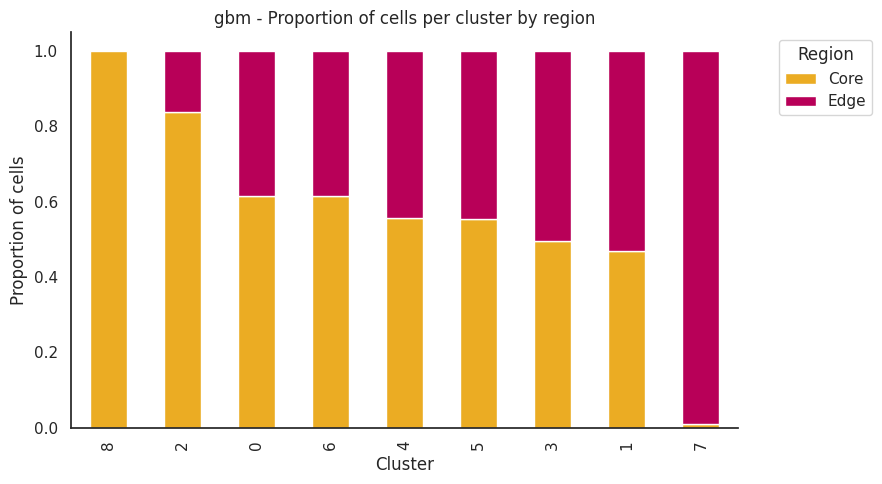

In [9]:
### plot proportions of cells types in each cluster by region
df['Region'] = df['Region'].astype('category')
df['rctd_cell_type'] = df['rctd_cell_type'].astype('category')
df[target_res] = df[target_res].astype('category')


# Count cells per (cluster, region)
df_counts = df.groupby([target_res, 'Region']).size().unstack().fillna(0)
df_counts = df_counts.sort_values(by='Core', ascending=False)

# Normalize to proportions (sum per cluster)
df_proportions = df_counts.div(df_counts.sum(axis=1), axis=0)
df_proportions = df_proportions.sort_values(by='Core', ascending=False)


# Plot
plt.figure(figsize=(9, 5))
df_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=plt.gca())
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Proportion of cells')
plt.xlabel('Cluster')
plt.title(f'{sample_name} - Proportion of cells per cluster by region')

### remove the top and right spines from plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(save_dir + f'{sample_name}_proportion_cells_per_cluster_by_region.png', dpi=300)

In [10]:
df_core = df[df['Region']=='Core']
df_edge = df[df['Region']=='Edge']

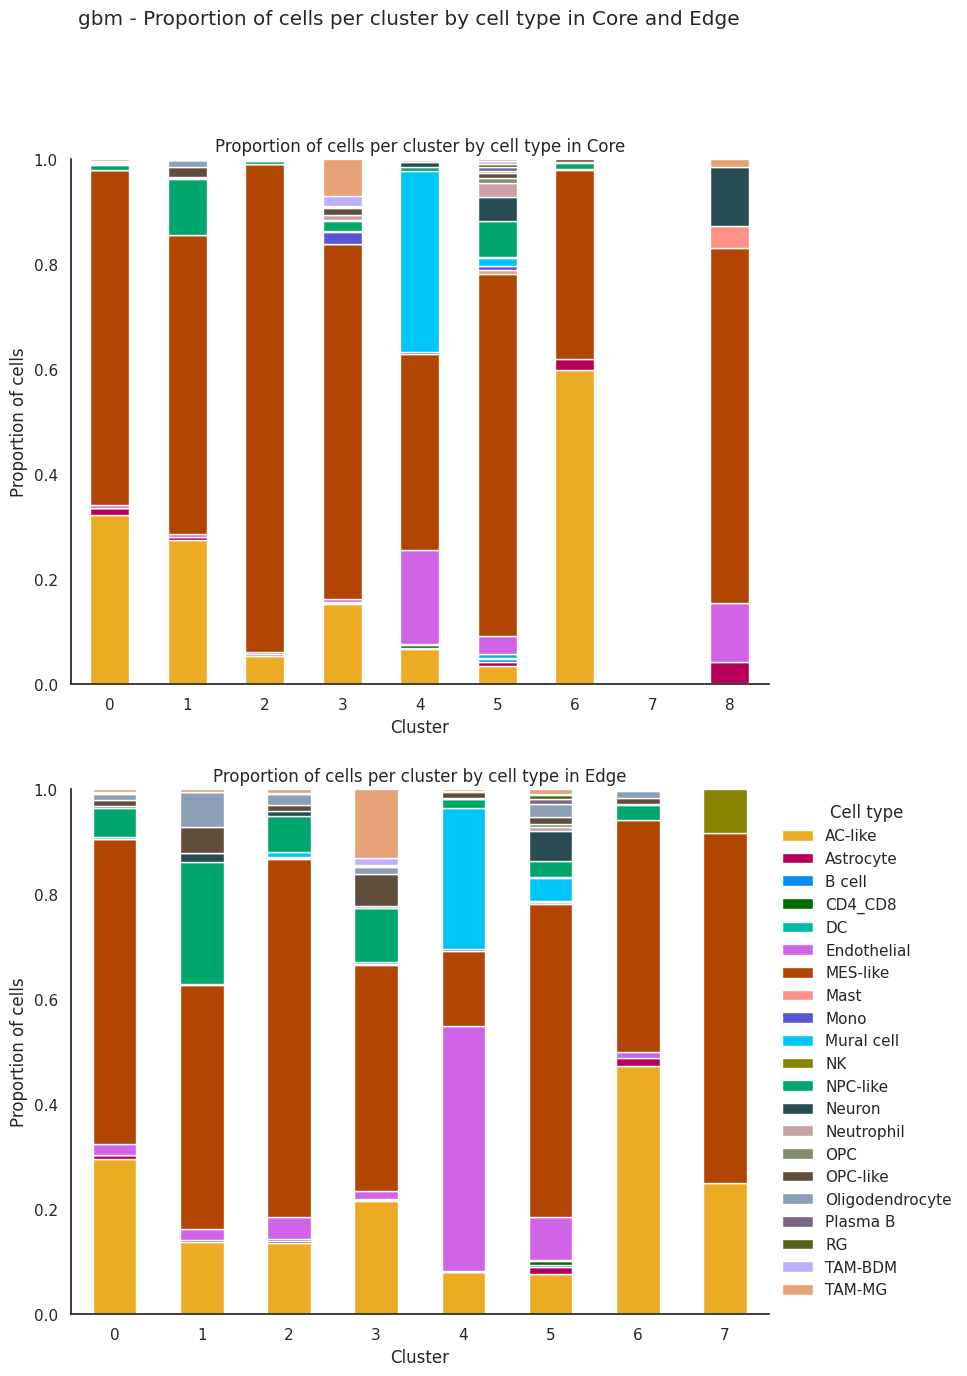

In [16]:
### plot proportions of cells types in each cluster by region
df_core_counts = df_core.groupby([target_res, 'rctd_cell_type']).size().unstack().fillna(0)
df_core_proportions = df_core_counts.div(df_core_counts.sum(axis=1), axis=0)


df_edge_counts = df_edge.groupby([target_res, 'rctd_cell_type']).size().unstack().fillna(0)
df_edge_proportions = df_edge_counts.div(df_edge_counts.sum(axis=1), axis=0)

fig, axs = plt.subplots(2, 1, figsize=(9, 15))
fig.suptitle(f'{sample_name} - Proportion of cells per cluster by cell type in Core and Edge')

df_core_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=axs[0])
axs[0].legend_.remove()
axs[0].set_ylabel('Proportion of cells')
axs[0].set_xlabel('Cluster')
axs[0].set_title('Proportion of cells per cluster by cell type in Core')
axs[0].set_xticklabels(df_core_proportions.index, rotation=0)
axs[0].set_ylim(0, 1)


df_edge_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=axs[1])
axs[1].legend(title='Cell type', bbox_to_anchor=(1, 1), frameon=False)
axs[1].set_ylabel('Proportion of cells')
axs[1].set_xlabel('Cluster')
axs[1].set_title('Proportion of cells per cluster by cell type in Edge')
axs[1].set_xticklabels(df_edge_proportions.index, rotation=0)
axs[1].set_ylim(0, 1)

sns.despine()
plt.savefig(save_dir + f'{sample_name}_proportion_cells_per_cluster_by_cell_type.png', dpi=300)

### Spatial interaction mapping

Spatial interaction analysis between cell types

In [17]:
data_core = data[data.obs['Region']=='Core']
data_edge = data[data.obs['Region']=='Edge']

In [18]:
scimap.tl.spatial_interaction(data, 
                    x_coordinate='x_centroid', 
                    y_coordinate='y_centroid', 
                    z_coordinate=None, 
                    phenotype='rctd_cell_type', 
                    method='knn', 
                    knn=9, 
                    permutation=1000, 
                    imageid='Region', 
                    subset=None, 
#                    pval_method='zscore', 
                    verbose=True, 
                    label='spatial_interaction_region')

Processing Image: ['Edge']
Categories (1, object): ['Edge']
Identifying the 9 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 1000 permutations
Consolidating the permutation results
Processing Image: ['Core']
Categories (1, object): ['Core']
Identifying the 9 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 1000 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 91325 × 216
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core_id',

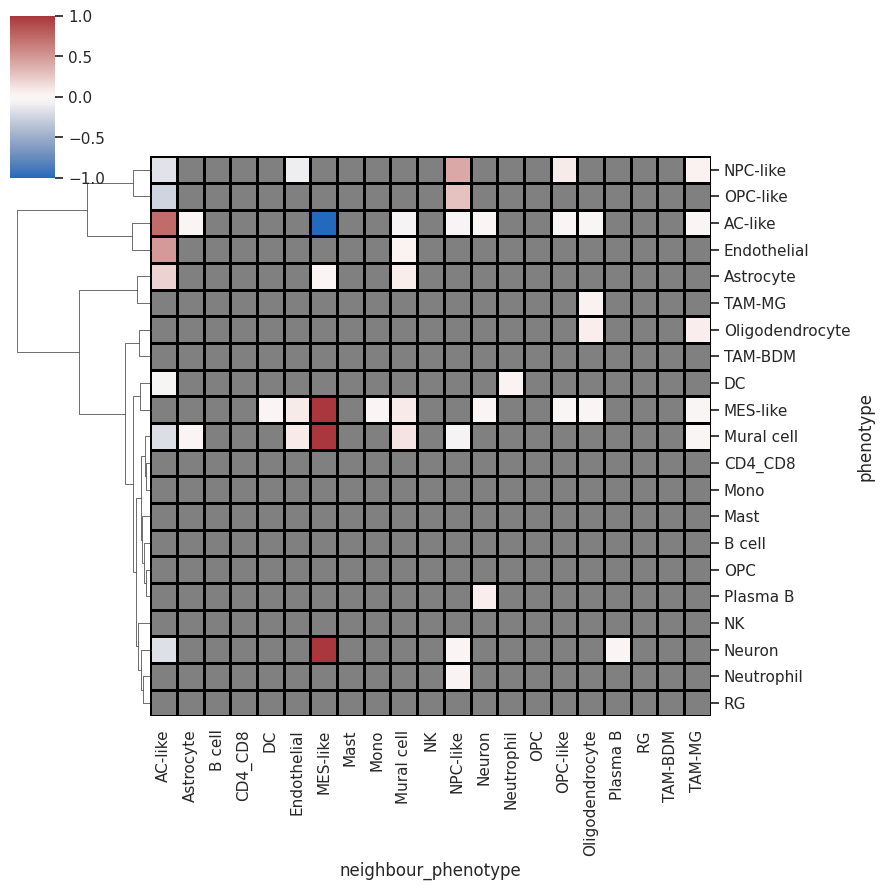

<Figure size 640x480 with 0 Axes>

In [19]:
scimap.pl.spatial_interaction(data, 
                          spatial_interaction='spatial_interaction_region',
                          yticklabels=True, 
                          figsize=(9,9), 
                          row_cluster=True,
                          summarize_plot=True,
                          p_val=0.001,
                          cmap='vlag',
                          linewidths=0.75, linecolor='black')

plt.savefig(save_dir+ f'/script09b_fig2_{sample_name}_spatial_interaction_region_summarized.pdf', bbox_inches='tight')


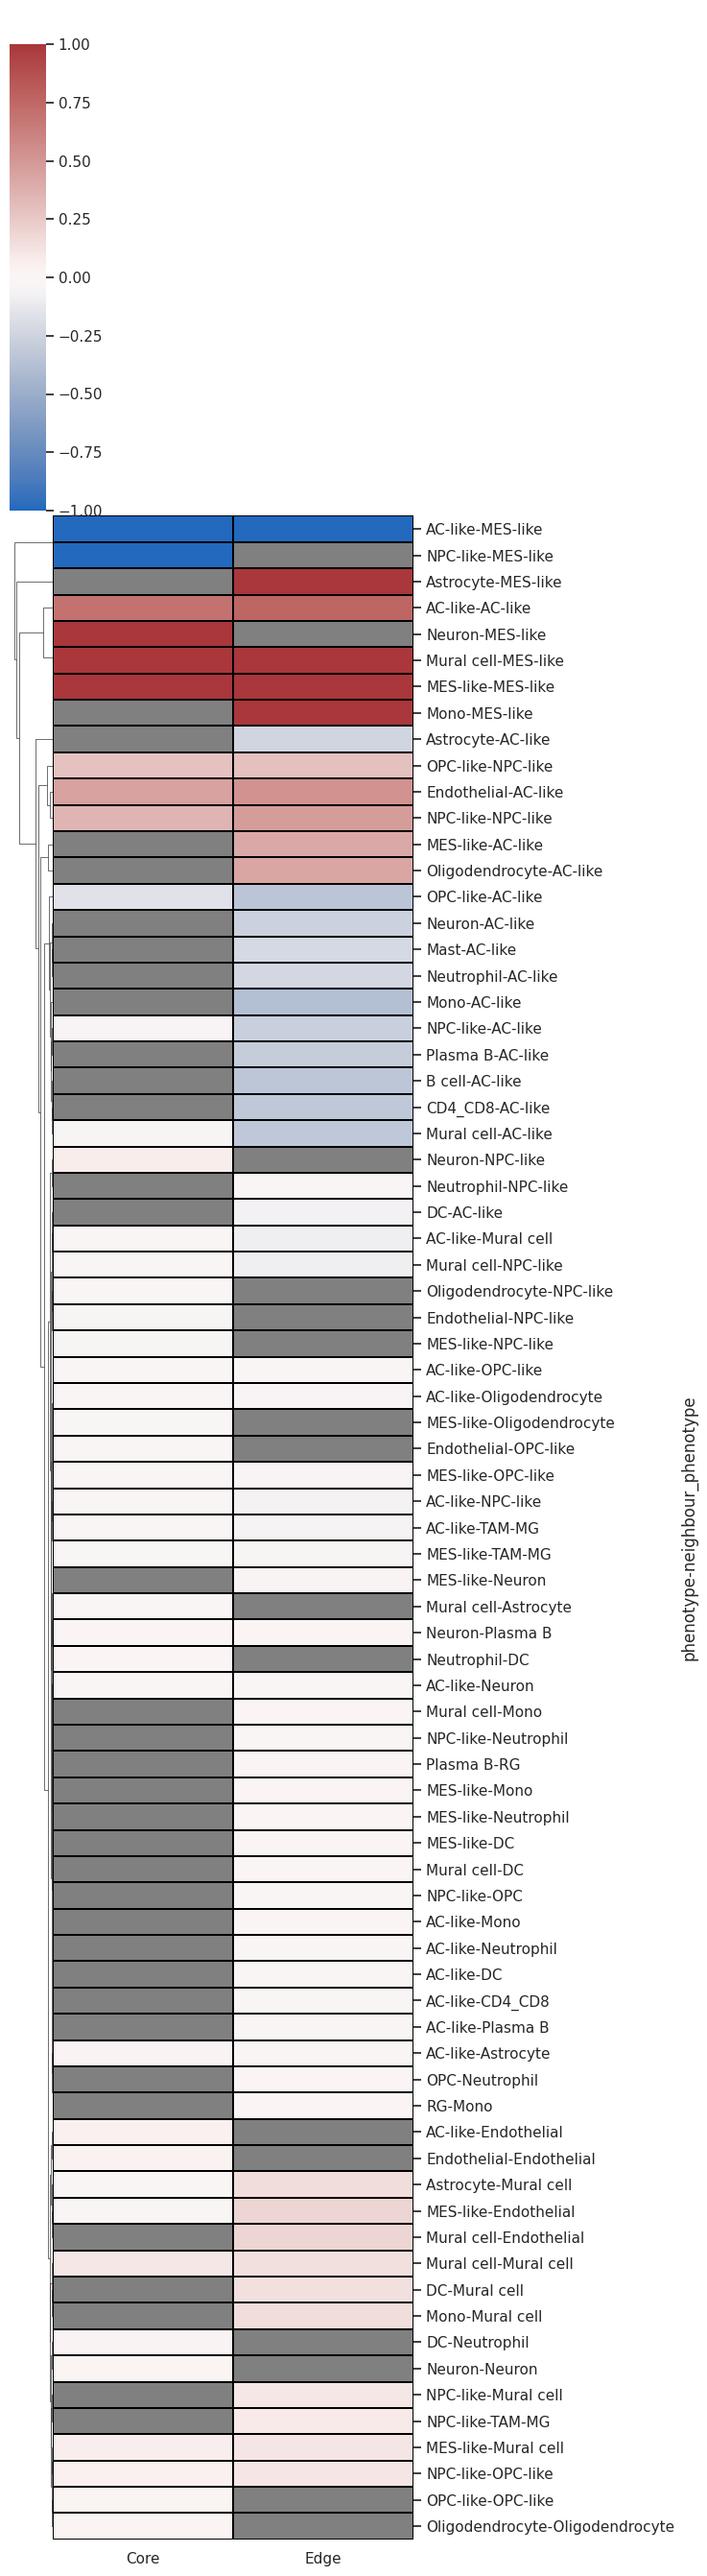

In [20]:
scimap.pl.spatial_interaction(data, 
                          spatial_interaction='spatial_interaction_region',
                          yticklabels=True, 
                          figsize=(7.5,27), 
                          row_cluster=True,
                          summarize_plot=False,
                          linewidths=0.01, 
                          p_val=0.000001,
                          #binary_view=True,
                          #pval_method = 'zscore',
                          linecolor='black',
                          dendrogram_ratio=(.1, .2))

#plt.savefig(save_dir+ f'/script09b_fig2_{sample_name}_spatial_interaction_region_summarized.pdf', bbox_inches='tight')pval_method

In [21]:
tumor_types = data.obs['rctd_cell_type'].unique().tolist()
tumor_types = ['RG',
 #'Mural cell',
 'Astrocyte',
 'OPC-like',
 'AC-like',
 'Endothelial',
# 'Mono',
 'NPC-like',
# 'TAM-BDM',
# 'DC',
 'MES-like',
# 'TAM-MG',
# 'CD4/CD8',
 'OPC',
# 'Plasma B',
# 'Neutrophil',
# 'B cell',
# 'Mast',
 'Neuron',
# 'NK',
 'Oligodendrocyte'
 ]

In [22]:
### subset data by keeping only tumor types

data_ttypes = data[data.obs['rctd_cell_type'].isin(tumor_types)]
data_ttypes

View of AnnData object with n_obs × n_vars = 35060 × 216
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'c

In [23]:
scimap.tl.spatial_interaction(data_ttypes, 
                    x_coordinate='x_centroid', 
                    y_coordinate='y_centroid', 
                    z_coordinate=None, 
                    phenotype='rctd_cell_type', 
                    method='knn', 
                    knn=3, 
                    permutation=500, 
                    imageid='Region', 
                    subset=None, 
                    pval_method='zscore', 
                    verbose=True, 
                    label='spatial_interaction_region')

Processing Image: ['Edge']
Categories (1, object): ['Edge']
Identifying the 3 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 500 permutations


Consolidating the permutation results
Processing Image: ['Core']
Categories (1, object): ['Core']
Identifying the 3 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 500 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 35060 × 216
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core_id',

In [24]:
data_ttypes.uns['spatial_interaction_region']


,phenotype,neighbour_phenotype,Edge,pvalue_Edge,Core,pvalue_Core
0,AC-like,AC-like,0.772816,1.041979e-249,0.753916,0.000000e+00
1,AC-like,Astrocyte,-0.008373,4.344074e-03,0.026781,1.913945e-13
2,AC-like,Endothelial,0.228579,2.583167e-03,0.064426,4.431775e-08
3,AC-like,MES-like,-1.000000,4.126826e-24,-1.000000,4.041207e-284
4,AC-like,NPC-like,-0.058052,1.236744e-99,-0.009096,1.172302e-47
...,...,...,...,...,...,...
95,RG,Neuron,0.055556,9.127733e-02,-0.000000,6.425832e-01
96,RG,OPC,-0.000000,8.653599e-01,-0.000000,8.755163e-01
97,RG,OPC-like,-0.000000,2.003082e-01,-0.000000,5.989137e-01
98,RG,Oligodendrocyte,-0.027778,7.836624e-01,-0.000000,7.115069e-01


In [25]:
df = data_ttypes.uns['spatial_interaction_region']

df_subset = df[(df['pvalue_Core'] < 0.0001) | (df['pvalue_Edge'] < 0.0001)]
df_subset = df_subset[(df_subset['Core'] > 0.25) | (df_subset['Edge'] > 0.25)]

#df_subset = df_subset[df_subset['pvalue_Edge'] < 0.01]

df_subset['interaction'] = [x+' > '+y for x,y in zip(df_subset['phenotype'], df_subset['neighbour_phenotype'])]
df_subset


,phenotype,neighbour_phenotype,Edge,pvalue_Edge,Core,pvalue_Core,interaction
0,AC-like,AC-like,0.772816,1.041979e-249,0.753916,0.000000e+00,AC-like > AC-like
10,Astrocyte,AC-like,-0.226950,2.788891e-03,0.576471,1.643157e-07,Astrocyte > AC-like
20,Endothelial,AC-like,0.460790,8.797084e-03,0.474153,1.304022e-09,Endothelial > AC-like
23,Endothelial,MES-like,1.000000,9.541186e-01,-1.000000,4.587136e-11,Endothelial > MES-like
33,MES-like,MES-like,1.000000,8.908199e-48,1.000000,2.388291e-272,MES-like > MES-like
44,NPC-like,NPC-like,0.742777,0.000000e+00,0.311914,1.453135e-282,NPC-like > NPC-like
53,Neuron,MES-like,1.000000,1.473482e-05,1.000000,4.804720e-01,Neuron > MES-like
74,OPC-like,NPC-like,0.562500,4.075131e-56,0.194969,5.793625e-19,OPC-like > NPC-like
83,Oligodendrocyte,MES-like,-1.000000,4.609492e-01,1.000000,6.299448e-05,Oligodendrocyte > MES-like


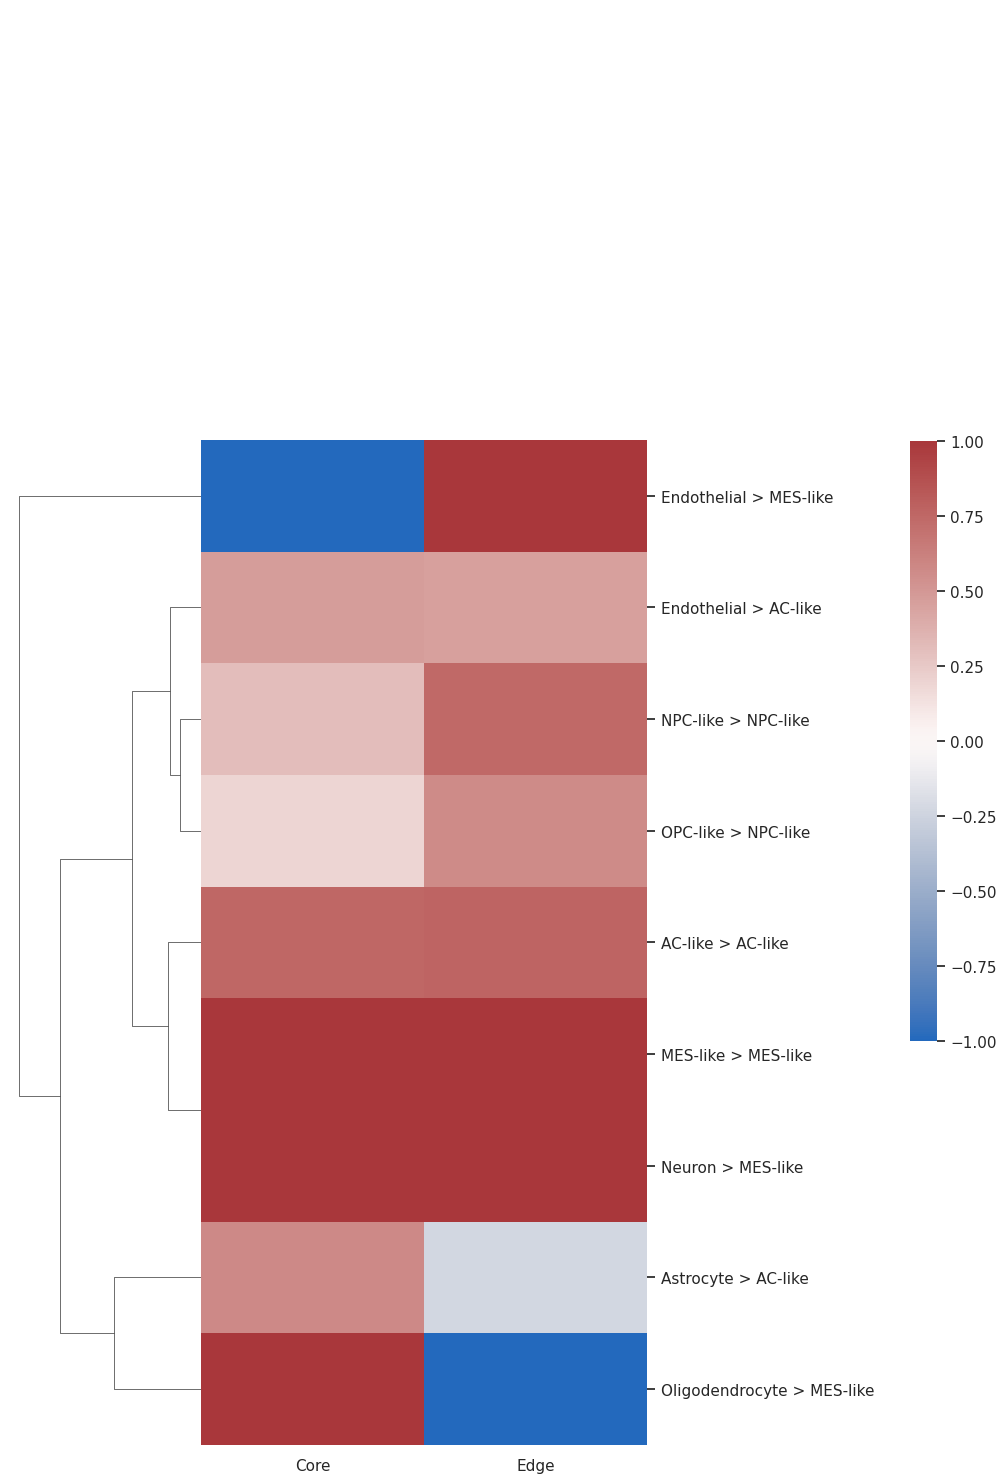

In [26]:
df_subset.index = df_subset['interaction'].tolist()

sns.clustermap(df_subset[['Core', 'Edge']],
                figsize=(9, 15), 
                cmap='vlag',
                row_cluster=True,
                col_cluster=False,
                cbar_pos=(1.02, 0.3, 0.03, 0.4),
                #cbar_kws={'label': 'p-value'},
                xticklabels=['Core', 'Edge'],
                #yticklabels=df_subset['interaction'].tolist(),
                dendrogram_ratio=(.3, .3),
                linewidths=0.001, 
                linecolor='black')

plt.savefig(save_dir + f'/script09b_fig3_{sample_name}_spatial_interaction_region_tumor_types.pdf', bbox_inches='tight', dpi=300)

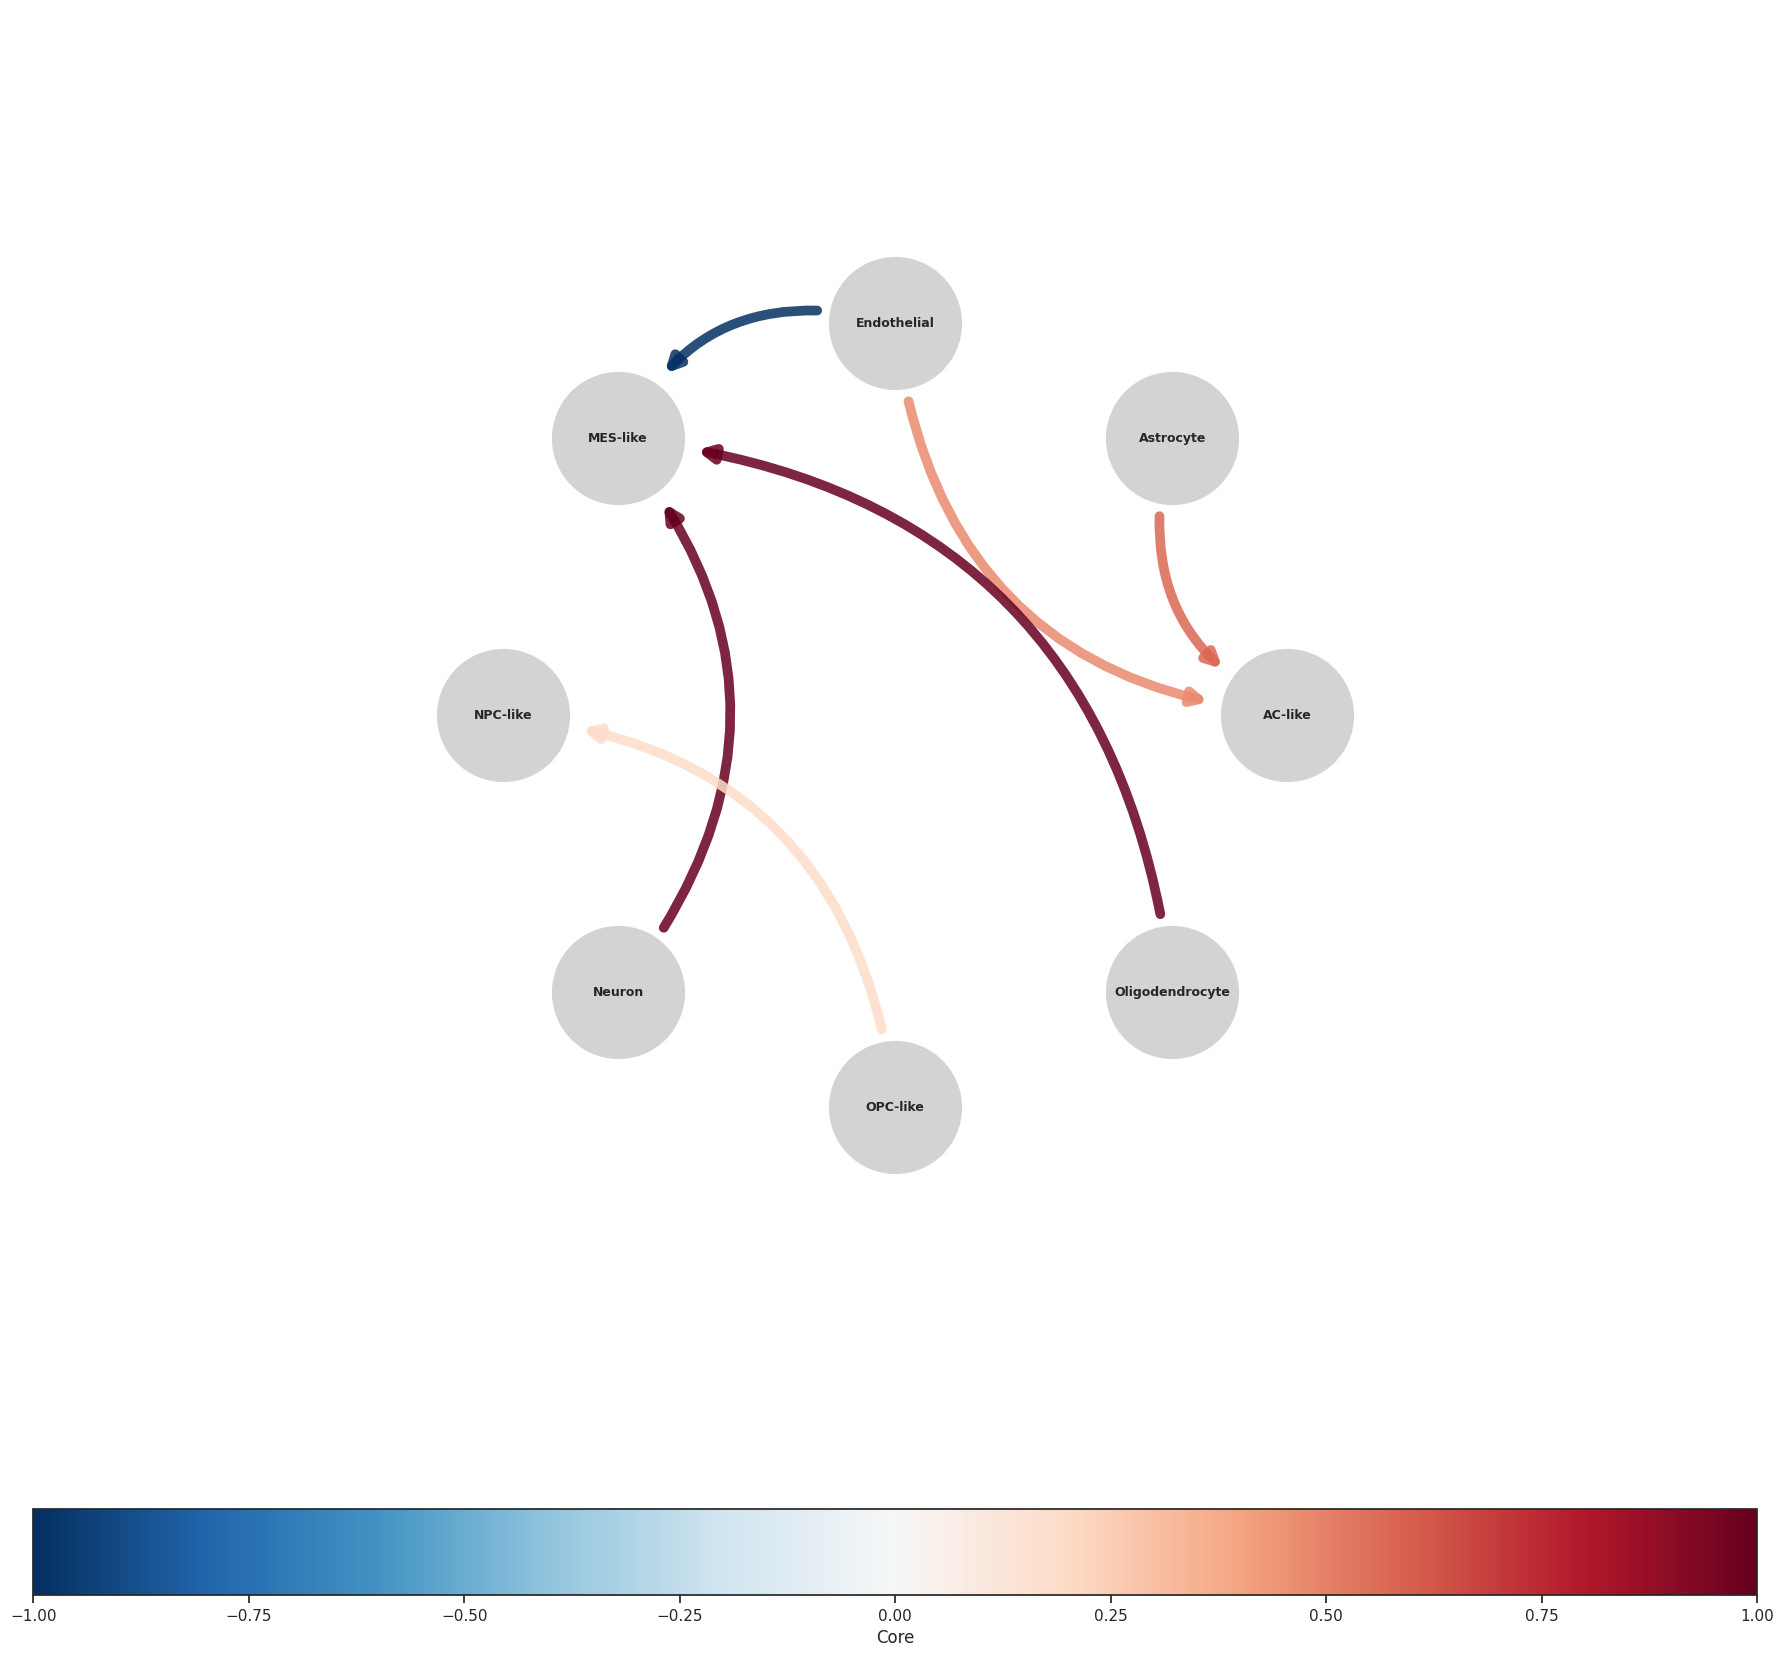

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch

def plot_circular_interactions(df_subset,
                               strength_col='Core',
                               cmap='RdBu_r',
                               arrow_width=7,
                               arrow_alpha=0.85,
                               node_size=9000,
                               circle_radius=4.2,    # how “tight” the ring is
                               figsize=(18, 18),
                               save_path=None):
    # 1. Node positions on a circle of radius=circle_radius
    labels = sorted(set(df_subset['phenotype']).union(df_subset['neighbour_phenotype']))
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    coords = {
        lab: (circle_radius * np.cos(a), circle_radius * np.sin(a))
        for lab, a in zip(labels, angles)
    }

    # 2. Color norm
    strengths = df_subset[strength_col].values
    vmin, vmax = strengths.min(), strengths.max()
    if vmin < 0 < vmax:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_func = cm.get_cmap(cmap)

    # 3. Figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')
    ax.axis('off')

    # 4. Draw arrows first
    pairs = {tuple(x) for x in df_subset[['phenotype','neighbour_phenotype']].values}
    shrink = np.sqrt(node_size) * 0.6

    for _, row in df_subset.iterrows():
        src, tgt = row['phenotype'], row['neighbour_phenotype']
        x0, y0 = coords[src]
        x1, y1 = coords[tgt]
        color = cmap_func(norm(row[strength_col]))

        if src == tgt:
            idx = labels.index(src)
            ang = angles[idx]
            bx = np.cos(ang)*(circle_radius + node_size**0.5/30)
            by = np.sin(ang)*(circle_radius + node_size**0.5/30)
            start, end = (bx, by), (bx, by)
            rad = 0.6
        else:
            start, end = (x0, y0), (x1, y1)
            rad = -0.4 if (tgt, src) in pairs else 0.4

        arrow = FancyArrowPatch(
            start, end,
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle='-|>',
            mutation_scale=20,
            lw=arrow_width,
            color=color,
            alpha=arrow_alpha,
            shrinkA=shrink,
            shrinkB=shrink,
            zorder=1
        )
        ax.add_patch(arrow)

    # 5. Draw nodes on top
    for lab in labels:
        x, y = coords[lab]
        ax.scatter(x, y, s=node_size, color='lightgray', zorder=2)
        ax.text(x, y, lab, ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=3)

    # 6. Colorbar
    sm = cm.ScalarMappable(cmap=cmap_func, norm=norm)
    sm.set_array(strengths)
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label(strength_col)

    # 7. Explicit limits so circle_radius takes effect
    pad = node_size**0.5/30 + 0.2  # a small extra margin
    ax.set_xlim(-circle_radius - pad, circle_radius + pad)
    ax.set_ylim(-circle_radius - pad, circle_radius + pad)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.show()

plot_circular_interactions(df_subset,)

plt.savefig(save_dir+ f'/script09b_fig3_{sample_name}_spatial_interaction_core_tumor_types_circular_gb.jpg', dpi=300, bbox_inches='tight')

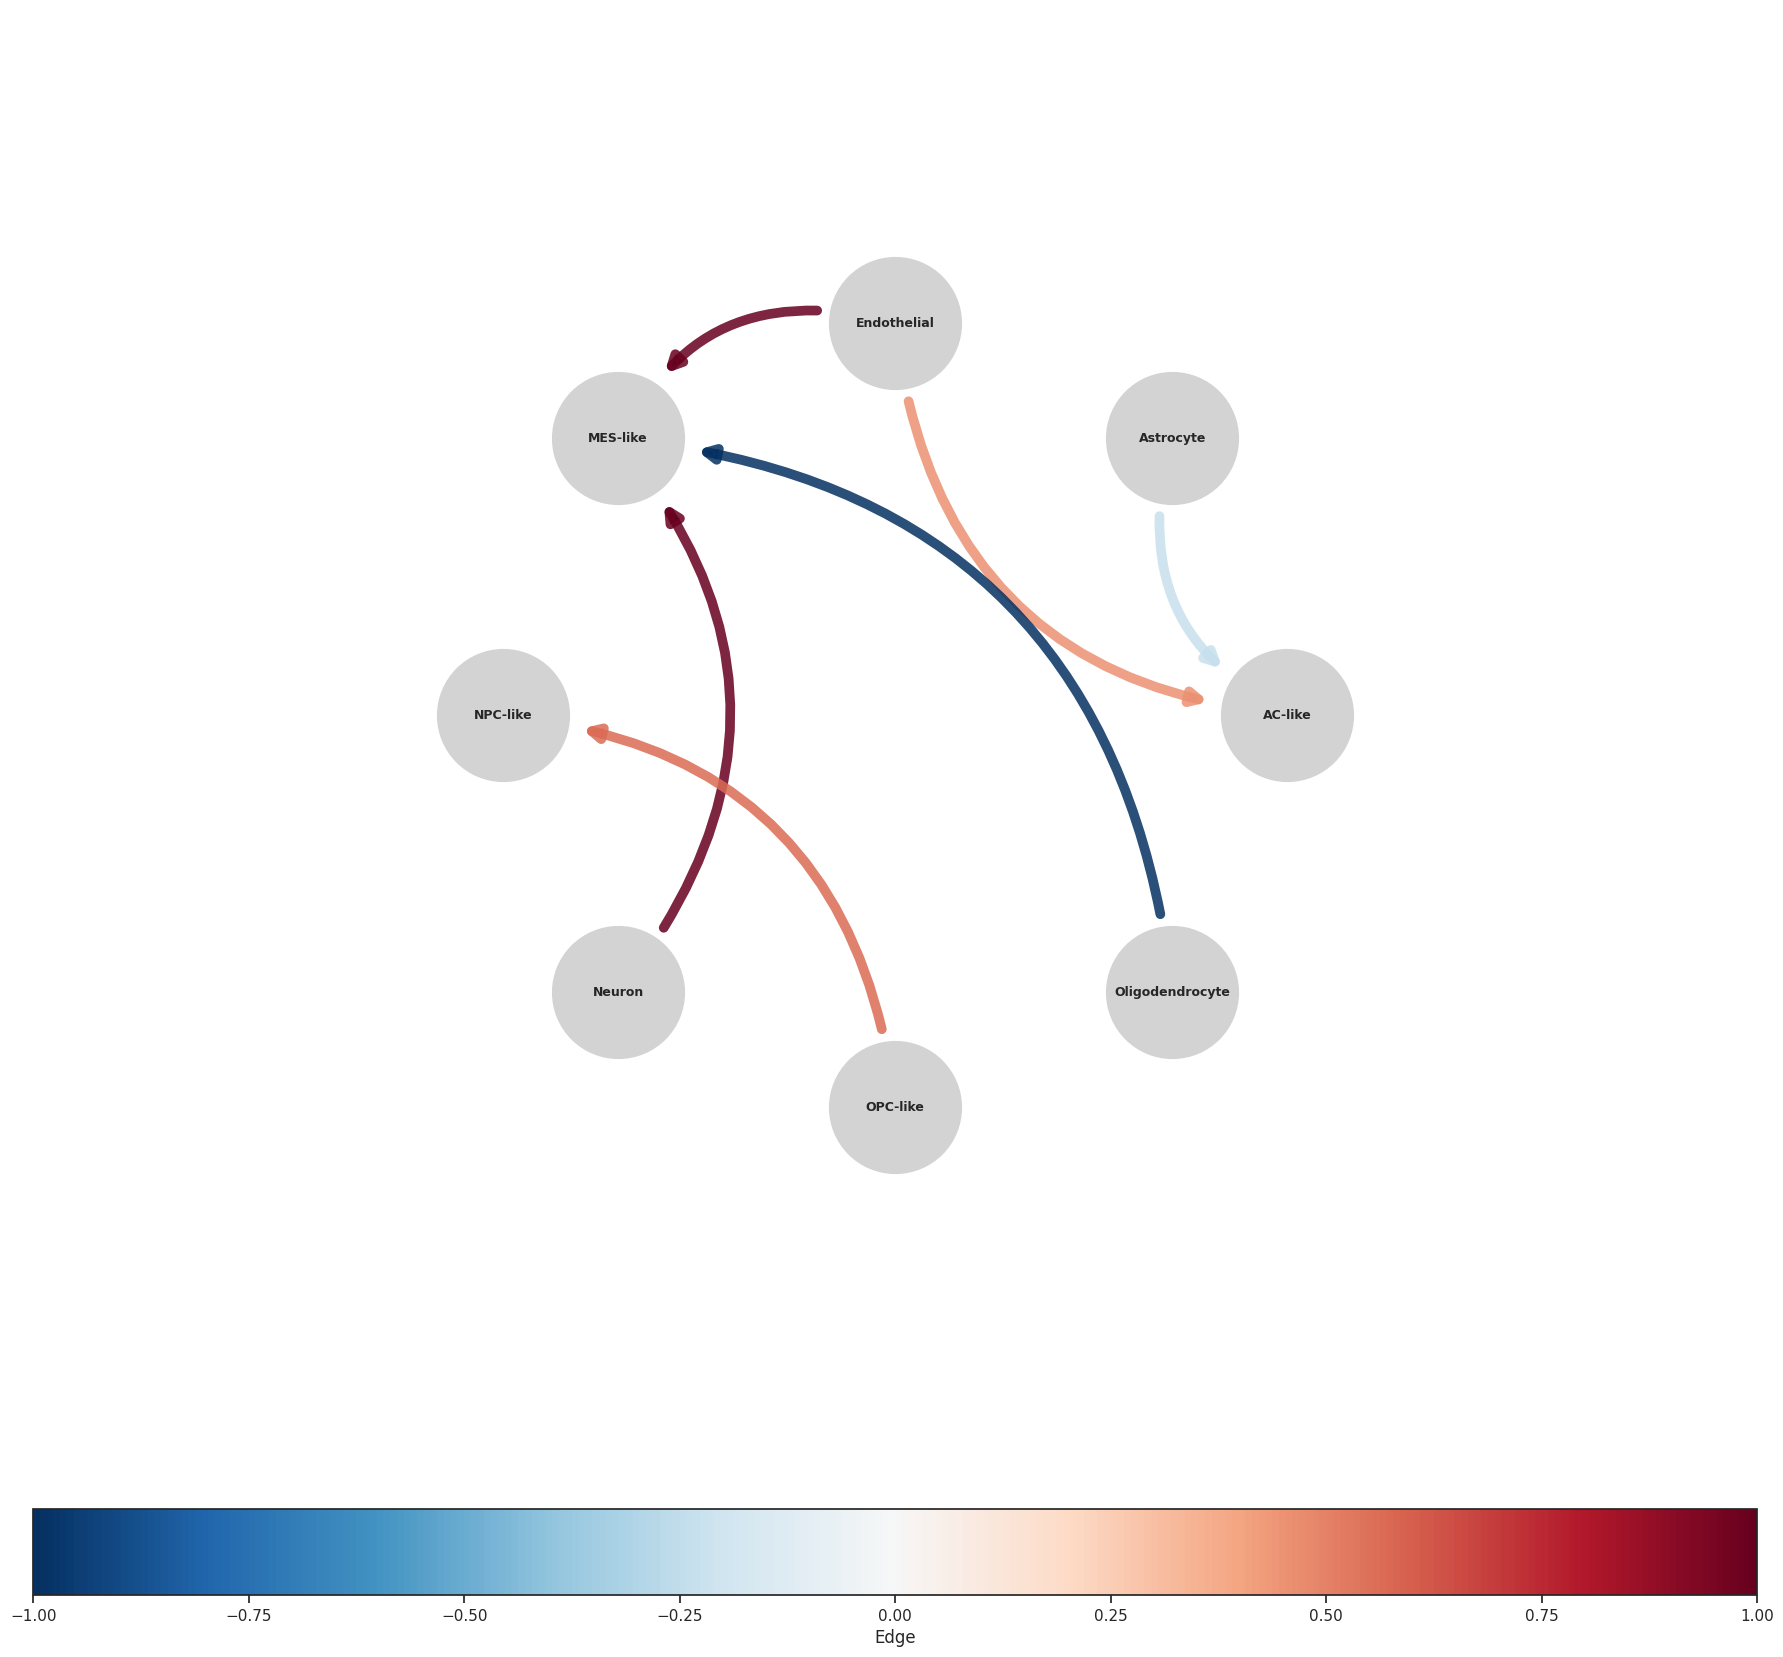

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch

def plot_circular_interactions(df_subset,
                               strength_col='Edge',
                               cmap='RdBu_r',
                               arrow_width=7,
                               arrow_alpha=0.85,
                               node_size=9000,
                               circle_radius=4.2,    # how “tight” the ring is
                               figsize=(18, 18),
                               save_path=None):
    # 1. Node positions on a circle of radius=circle_radius
    labels = sorted(set(df_subset['phenotype']).union(df_subset['neighbour_phenotype']))
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    coords = {
        lab: (circle_radius * np.cos(a), circle_radius * np.sin(a))
        for lab, a in zip(labels, angles)
    }

    # 2. Color norm
    strengths = df_subset[strength_col].values
    vmin, vmax = strengths.min(), strengths.max()
    if vmin < 0 < vmax:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_func = cm.get_cmap(cmap)

    # 3. Figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')
    ax.axis('off')

    # 4. Draw arrows first
    pairs = {tuple(x) for x in df_subset[['phenotype','neighbour_phenotype']].values}
    shrink = np.sqrt(node_size) * 0.6

    for _, row in df_subset.iterrows():
        src, tgt = row['phenotype'], row['neighbour_phenotype']
        x0, y0 = coords[src]
        x1, y1 = coords[tgt]
        color = cmap_func(norm(row[strength_col]))

        if src == tgt:
            idx = labels.index(src)
            ang = angles[idx]
            bx = np.cos(ang)*(circle_radius + node_size**0.5/30)
            by = np.sin(ang)*(circle_radius + node_size**0.5/30)
            start, end = (bx, by), (bx, by)
            rad = 0.6
        else:
            start, end = (x0, y0), (x1, y1)
            rad = -0.4 if (tgt, src) in pairs else 0.4

        arrow = FancyArrowPatch(
            start, end,
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle='-|>',
            mutation_scale=20,
            lw=arrow_width,
            color=color,
            alpha=arrow_alpha,
            shrinkA=shrink,
            shrinkB=shrink,
            zorder=1
        )
        ax.add_patch(arrow)

    # 5. Draw nodes on top
    for lab in labels:
        x, y = coords[lab]
        ax.scatter(x, y, s=node_size, color='lightgray', zorder=2)
        ax.text(x, y, lab, ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=3)

    # 6. Colorbar
    sm = cm.ScalarMappable(cmap=cmap_func, norm=norm)
    sm.set_array(strengths)
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label(strength_col)

    # 7. Explicit limits so circle_radius takes effect
    pad = node_size**0.5/30 + 0.2  # a small extra margin
    ax.set_xlim(-circle_radius - pad, circle_radius + pad)
    ax.set_ylim(-circle_radius - pad, circle_radius + pad)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.show()

plot_circular_interactions(df_subset,)

plt.savefig(save_dir+ f'/script09b_fig3_{sample_name}_spatial_interaction_edge_tumor_types_circular_gb.jpg', dpi=300, bbox_inches='tight')

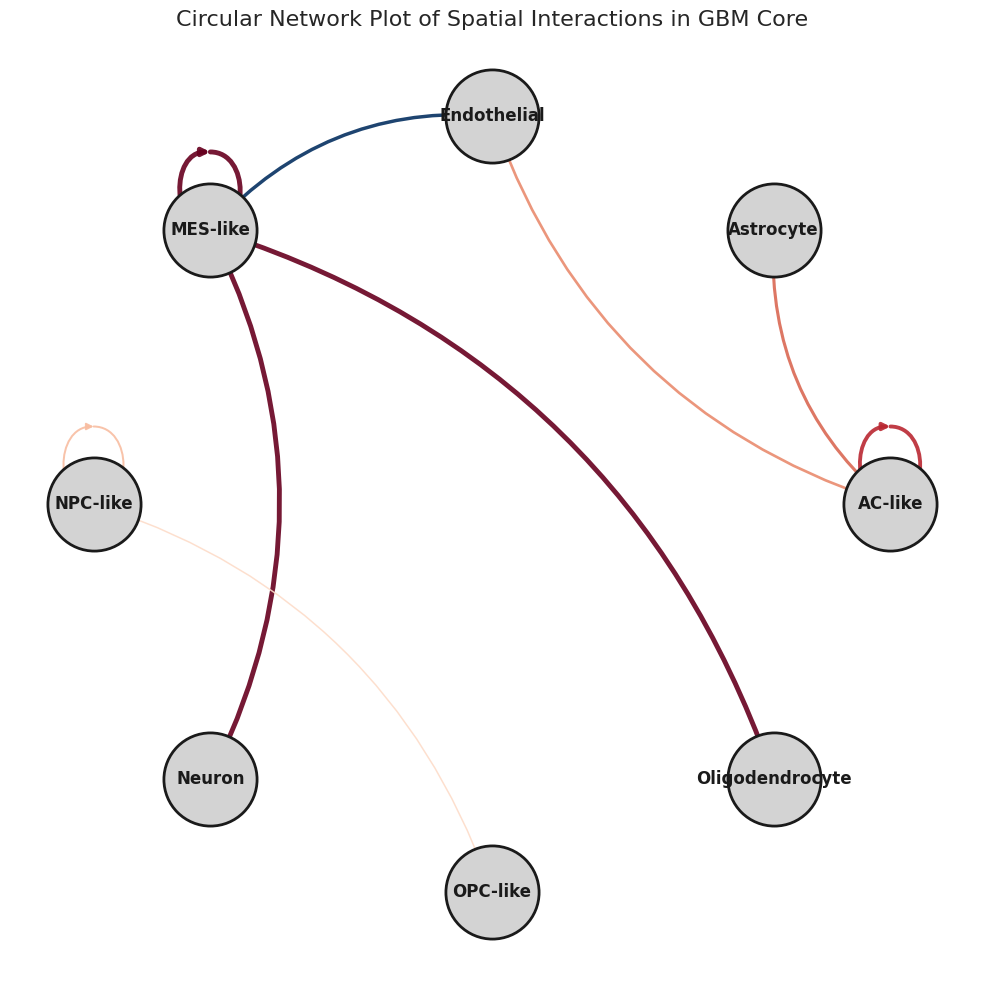

In [29]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Get unique nodes
labels = sorted(set(df_subset['phenotype']).union(df_subset['neighbour_phenotype']))
label_to_idx = {lab: i for i, lab in enumerate(labels)}

# Build a directed graph (use nx.Graph() for undirected)
G = nx.DiGraph()
G.add_nodes_from(labels)

# Add edges with weights (strength)
for _, row in df_subset.iterrows():
    src = row['phenotype']
    tgt = row['neighbour_phenotype']
    weight = row['Core']  # or other column
    if G.has_edge(src, tgt):
        G[src][tgt]['weight'] += weight
    else:
        G.add_edge(src, tgt, weight=weight)


# Arrange nodes in a circle
pos = nx.circular_layout(G)

# Extract edge weights for line thickness
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights) if weights else 1

# Normalize weights for plotting (adjust the scaling factor as you like)
widths = [0.5 + 3*w/max_weight for w in weights]

# Draw nodes
plt.figure(figsize=(10,10))
nx.draw_networkx_nodes(G, pos, node_size=4500, node_color='lightgray', linewidths=2, edgecolors='k')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw edges (links)
nx.draw_networkx_edges(
    G, pos,
    width=widths,
    arrowstyle='-|>',
    arrowsize=10,
    edge_color=weights,
    edge_cmap=plt.cm.RdBu_r,
    connectionstyle='arc3,rad=0.25', # arc edges for clarity
    alpha=0.9
)

plt.title('Circular Network Plot of Spatial Interactions in GBM Core', fontsize=16)
plt.axis('off')
plt.tight_layout()
#plt.savefig(save_dir + f'/circleplot_spatial_interaction_{sample_name}.jpg', dpi=300, bbox_inches='tight')
plt.show()


### Network Chord Diagrams


<Figure size 1400x1600 with 0 Axes>

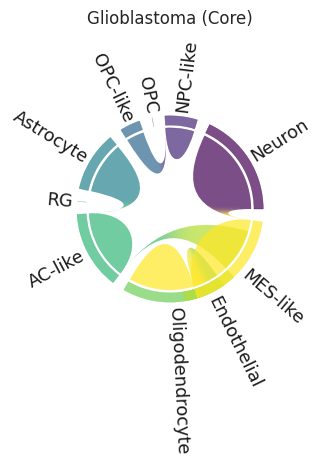

In [32]:
import pandas as pd
from mpl_chord_diagram import chord_diagram
import matplotlib.pyplot as plt

# Define custom order for labels
labels_ordered = [
    "Neuron","NPC-like","OPC","OPC-like",
    "Astrocyte","RG","AC-like",
    "Oligodendrocyte","Endothelial","MES-like"
]

# Create square matrix initialized with zeros
matrix = pd.DataFrame(0, index=labels_ordered, columns=labels_ordered)

# Fill matrix with interaction strengths
for _, row in df_subset.iterrows():
    src = row['phenotype']
    tgt = row['neighbour_phenotype']
    value = row['Core']  # or your chosen column
    if src in matrix.index and tgt in matrix.columns:
        matrix.loc[src, tgt] += value  # accumulate values

# Plot
plt.figure(figsize=(14, 16))

chord_diagram(
    matrix.values,
    names=labels_ordered,   # use the ordered labels!
    use_gradient=True,
    font_size=11,
    sort='distance',         # don’t reshuffle automatically
    wrap_labels=False,
    pad=8,                 # increase spacing
    rotate_names=True
)

plt.title('Glioblastoma (Core)', fontsize=12, pad=60)
plt.tight_layout()
plt.savefig(save_dir + f'/chord_spatial_interaction_Core_{sample_name}.jpg',
            dpi=300, bbox_inches='tight')
plt.show()


<Figure size 1400x1600 with 0 Axes>

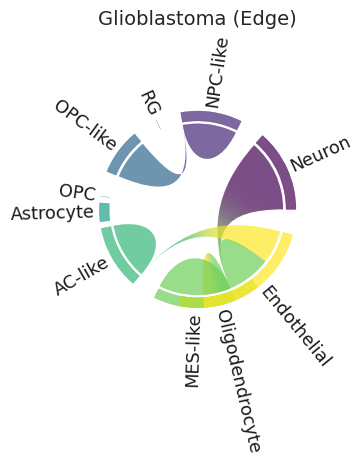

In [54]:
import pandas as pd
from mpl_chord_diagram import chord_diagram
import matplotlib.pyplot as plt

labels_ordered = [
    "Neuron", "NPC-like", "RG", "OPC-like", "OPC",
    "Astrocyte", "AC-like", "MES-like", "Oligodendrocyte", "Endothelial"
]



# Create square matrix initialized with zeros
matrix = pd.DataFrame(0, index=labels_ordered, columns=labels_ordered)

# Fill matrix with interaction strengths
for _, row in df_subset.iterrows():
    src = row['phenotype']
    tgt = row['neighbour_phenotype']
    value = row['Edge']  # or your chosen column
    if src in matrix.index and tgt in matrix.columns:
        matrix.loc[src, tgt] += value  # accumulate values

# Plot
plt.figure(figsize=(14, 16))

chord_diagram(
    matrix.values,
    names=labels_ordered,   # use the ordered labels!
    use_gradient=True,
    font_size=11,
    sort='distance',         # don’t reshuffle automatically
    wrap_labels=False,
    pad=15,                 # increase spacing,
    rotate_names=True
)

plt.title('Glioblastoma (Edge)', fontsize=14, pad=55)
plt.tight_layout()
plt.savefig(save_dir + f'/chord_spatial_interaction_Edge_{sample_name}.jpg',
            dpi=300, bbox_inches='tight')
plt.show()
